# Importación librerías

In [36]:
import folium
import seaborn as sns
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from pathlib import Path
from glob import glob

# Carga de los datos de medición

## Monitoreo DINACEA

In [37]:
mediciones_path = Path("../datos/mediciones/extraccion_20250807-184309.csv")
mediciones = pd.read_csv(
    mediciones_path,
    encoding='UTF-8',
    delimiter=';',
    low_memory=False
)

## Boyas automáticas

In [38]:
xlsx = glob("../datos/mediciones/Blanvira_Rincón del Bonete/*.xlsx")

df = pd.concat(pd.read_excel(excel_file) for excel_file in xlsx)
df["Fecha del dato"] = pd.to_datetime(df["Fecha del dato"])

daily_mean = df.groupby([df['Fecha del dato'].dt.date, df['Parametro']])['Valor'].mean().to_frame().reset_index()

## Descripción de los datos

In [39]:
print("Cantidad de días monitoreados DINACEA", len(list(mediciones.fecha_muestra.unique())))
print("Cantidad de días monitoreados DINACEA en Rincón de Bonete",
      len(
          list(
              mediciones[mediciones["id_estacion"] == 100642].fecha_muestra.unique()))
     ) 
#mediciones[mediciones["id_estacion"] == 100642].groupby("param").fecha_muestra.count()

Cantidad de días monitoreados DINACEA 6282
Cantidad de días monitoreados DINACEA en Rincón de Bonete 40


In [40]:
df.columns
print("Cantidad de días Boyas", len(list(df['Fecha del dato'].unique())))
print("Cantidad de días Boyas en Rincón de Bonete",
      len(
          list(
              df['Fecha del dato'].unique()))
     ) 
#df.groupby("Parametro")['Fecha del dato'].count()

Cantidad de días Boyas 31751
Cantidad de días Boyas en Rincón de Bonete 31751


In [41]:
# filtrado por las estaciones de interés
# print("Parámetros medidos por boya automatica: \n", df.Parametro.unique())
boya_chla = df[df['Parametro']=='Clorofila a'].copy()
# print("Parámetros medidos por monitoreo: \n", mediciones.param.unique())
monintoreo_bonete = mediciones[mediciones["id_estacion"] == 100642].copy()
monitoreo_chla = monintoreo_bonete[monintoreo_bonete["param"]=='Clo_a'].copy() # 'Clo_a' 'CloA_(in_situ_color)' 'CloA_(in_situ_ug)'
# monitoreo_chla.columns
monitoreo_chla['valor_original'] = monitoreo_chla['valor_original'].replace('<LC', None)
monitoreo_chla['valor_original'] = pd.to_numeric(monitoreo_chla['valor_original'], errors='coerce')

# monitoreo_chla_a.head()
monitoreo_tur = monintoreo_bonete[monintoreo_bonete["param"]=='Transp'].copy()

# Localización de los puntos

In [42]:
# Coordenadas dos pontos com nomes e cores
pontos = [
    {"coordenadas": (-32.828667, -56.418), "nombre": "Monitoreo N. 100642", "cor": "orange"},
    # {"coordenadas": (-32.823319, -56.419437), "nombre": "Monitoreo N. 100255", "cor": "orange"},
    {"coordenadas": (-32.829722, -56.418889), "nombre": "Boya N. 649", "cor": "blue"}
]

# Criar o mapa centralizado no primeiro ponto
m = folium.Map(location=pontos[0]["coordenadas"], zoom_start=15)

# Adicionar os marcadores com cores diferentes
for ponto in pontos:
    folium.Marker(
        location=ponto["coordenadas"],
        popup=ponto["nombre"],
        icon=folium.Icon(color=ponto["cor"])
    ).add_to(m)

m

# Comparativos de valores de Chl_a

In [43]:
print("Valores boya")
boya_chla.groupby('Parametro').Valor.describe()

Valores boya


,count,mean,std,min,25%,50%,75%,max
Parametro,,,,,,,,
Clorofila a,30053.0,1.421113,1.68743,0.0,0.56,0.94,1.92,38.09


In [44]:
print("Valores monitoreo")
monitoreo_chla.groupby('parametro').valor_original.describe()

Valores monitoreo


,count,mean,std,min,25%,50%,75%,max
parametro,,,,,,,,
Clorofila_a_(lab),34.0,26.397059,48.97912,1.5,3.0,10.4,30.25,266.4


### ¿Cómo se distribuyen los valores de Chl_a a lo largo del tiempo?

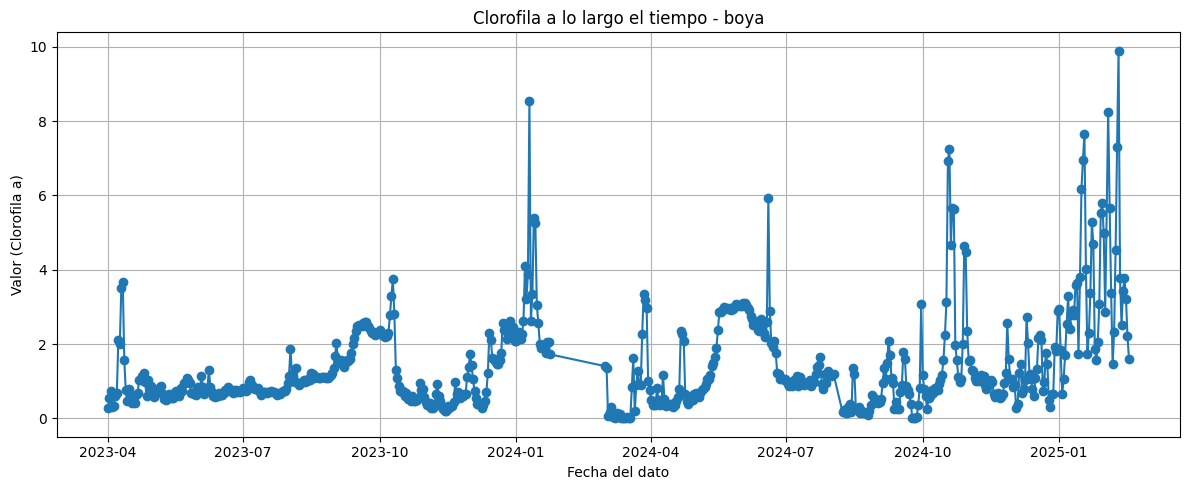

In [45]:
boya_chla_daily = daily_mean[daily_mean['Parametro']=='Clorofila a'].reset_index(drop=True)
plt.figure(figsize=(12, 5))
plt.plot(boya_chla_daily['Fecha del dato'], boya_chla_daily['Valor'], marker='o', linestyle='-')
plt.xlabel('Fecha del dato')
plt.ylabel('Valor (Clorofila a)')
plt.title('Clorofila a lo largo el tiempo - boya')
plt.grid(True)
plt.tight_layout()
plt.show()

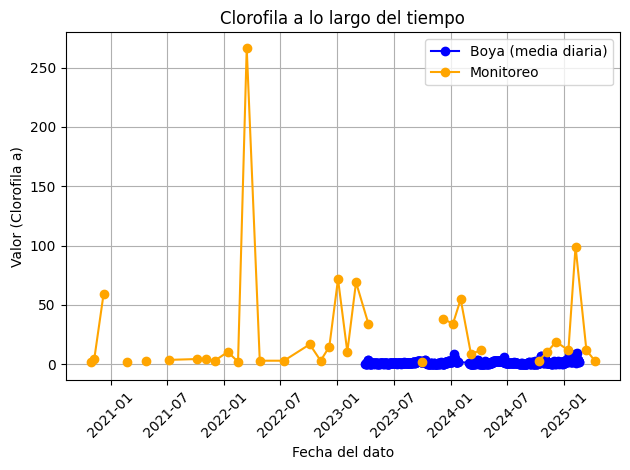

In [46]:
monitoreo_chla.fecha_muestra = pd.to_datetime(monitoreo_chla.fecha_muestra)
monitoreo_chla.sort_values('fecha_muestra', inplace=True)
monitoreo_tur.sort_values('fecha_muestra', inplace=True)

# Plot 1 - boya
plt.plot(
    boya_chla_daily['Fecha del dato'],
    boya_chla_daily['Valor'],
    marker='o',
    linestyle='-',
    color='blue',
    label='Boya (media diaria)'
)

# Plot 2 - monitoreo
plt.plot(
    monitoreo_chla['fecha_muestra'],
    monitoreo_chla['valor_original'],
    marker='o',
    linestyle='-',
    color='orange',
    label='Monitoreo'
)

# Ajustes do gráfico
plt.xlabel('Fecha del dato')
plt.ylabel('Valor (Clorofila a)')
plt.title('Clorofila a lo largo del tiempo')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### ¿Cual es la diferencia en los valores de Chla_a medidos por la estación automatica (boya) y el monitoreo, en el Ricón del Bonete, Río Negro, para las mismas fechas?

In [47]:
boya_chla_daily['fecha'] = pd.to_datetime(boya_chla_daily['Fecha del dato']).dt.date
monitoreo_chla['fecha'] = pd.to_datetime(monitoreo_chla['fecha_muestra']).dt.date
monitoreo_tur['fecha'] = pd.to_datetime(monitoreo_tur['fecha_muestra']).dt.date
boya_chla_daily.rename(columns={'Valor': 'valor_boya'}, inplace=True)
monitoreo_chla.rename(columns={'valor_original': 'valor_monitoreo'}, inplace=True)
monitoreo_tur.rename(columns={'valor_original': 'valor_trans_monitoreo'}, inplace=True)
comparacao = pd.merge(boya_chla_daily, monitoreo_chla, on='fecha', how='inner')
comparacao2 = pd.merge(monitoreo_tur, monitoreo_chla, on='fecha', how='inner')

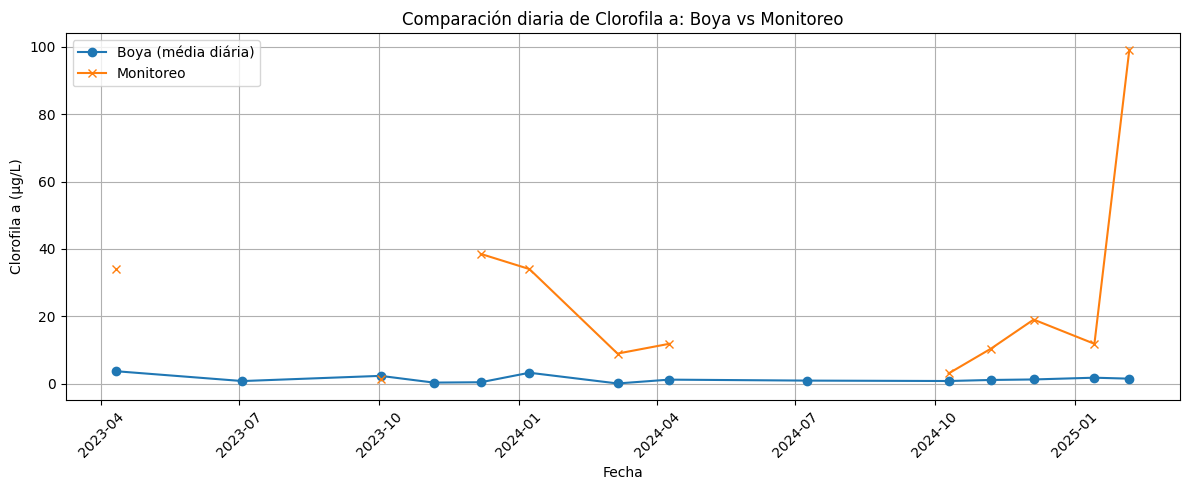

In [48]:
plt.figure(figsize=(12, 5))
plt.plot(comparacao['fecha'], comparacao['valor_boya'], label='Boya (média diária)', marker='o')
plt.plot(comparacao['fecha'], comparacao['valor_monitoreo'], label='Monitoreo', marker='x')
plt.xlabel('Fecha')
plt.ylabel('Clorofila a (μg/L)')
plt.title('Comparación diaria de Clorofila a: Boya vs Monitoreo')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

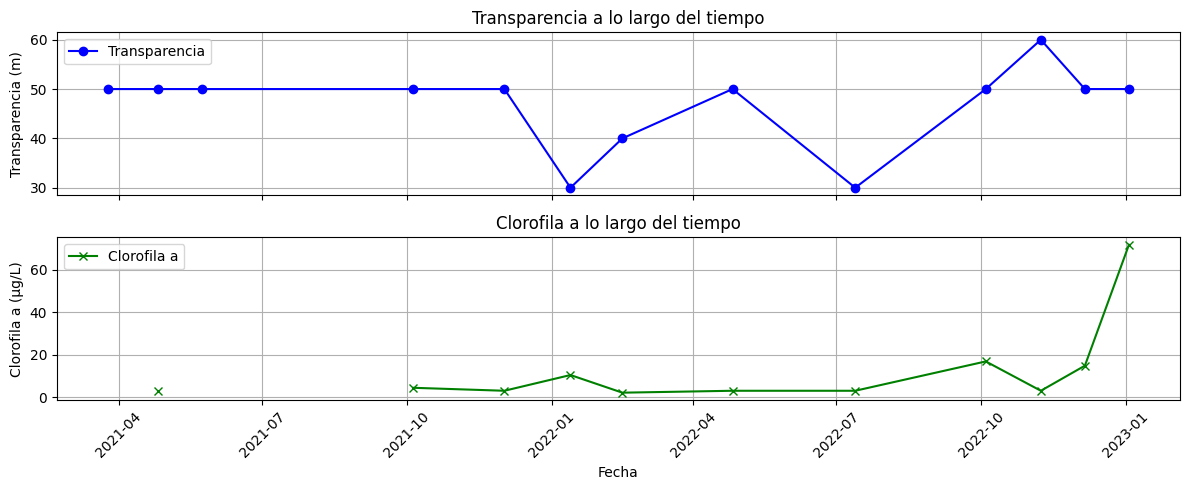

In [49]:
comparacao2['valor_trans_monitoreo'] = pd.to_numeric(comparacao2['valor_trans_monitoreo'], errors='coerce')

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

# Primeiro plot - Transparencia
axes[0].plot(comparacao2['fecha'], comparacao2['valor_trans_monitoreo'],
             label='Transparencia', marker='o', color='blue')
axes[0].set_ylabel('Transparencia (m)')
axes[0].set_title('Transparencia a lo largo del tiempo')
axes[0].legend()
axes[0].grid(True)

# Segundo plot - Clorofila a
axes[1].plot(comparacao2['fecha'], comparacao2['valor_monitoreo'],
             label='Clorofila a', marker='x', color='green')
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('Clorofila a (μg/L)')
axes[1].set_title('Clorofila a lo largo del tiempo')
axes[1].legend()
axes[1].grid(True)

# Ajustar layout
plt.xticks(rotation=45)
plt.tight_layout()

In [53]:
monintoreo_bonete['fecha_muestra'] = pd.to_datetime(monintoreo_bonete['fecha_muestra']).dt.date
monintoreo_bonete.sort_values('fecha_muestra', inplace=True)
# Obtenha a lista de parâmetros de forma ordenada (caso seja importante a ordem)
# unique_params = sorted(mediciones['param'].unique())
unique_params = [
    'CloA_(in_situ_ug)',
    'Clo_a',
    'Fico_(in_situ_ug)',
    'Fico_(lab)',
    'Transp',
    'Turb',]
# unique_params

monintoreo_bonete['valor_original'] = monintoreo_bonete['valor_original'].replace('<LC', None)
monintoreo_bonete['valor_original'] = monintoreo_bonete['valor_original'].replace('<LD', None)
monintoreo_bonete['valor_original'] = monintoreo_bonete['valor_original'].replace('NO ', None)
monintoreo_bonete['valor_original'] = pd.to_numeric(monintoreo_bonete['valor_original'], errors='coerce')

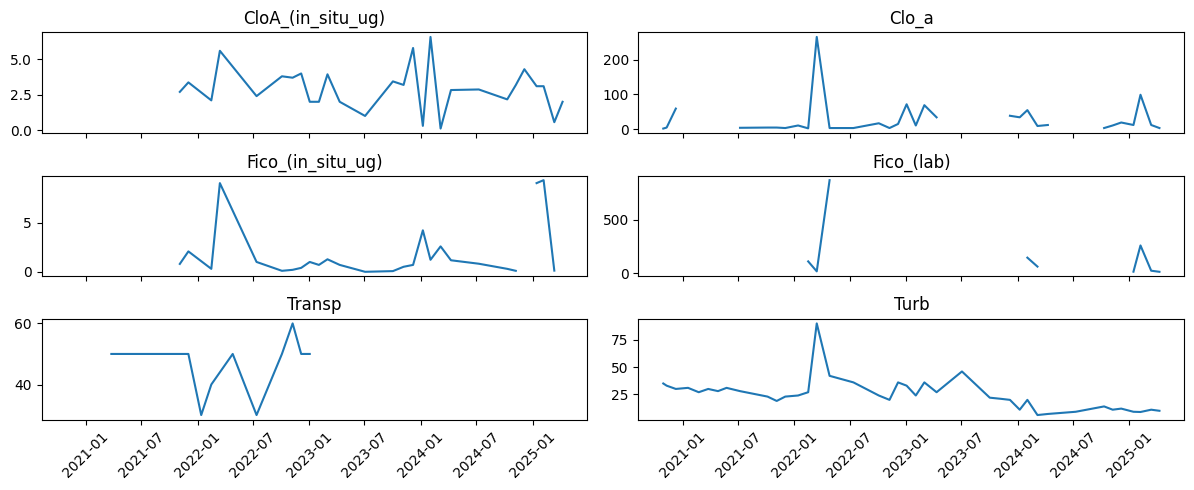

In [54]:
# Cria a figura com 4 linhas e 2 colunas
fig, axs = plt.subplots(3, 2, figsize=(12, 5), sharey=False, sharex=True)

axs = axs.ravel()  # Transforma a matriz de eixos em um vetor para facilitar a iteração

# Itera sobre cada parâmetro para plotar o respectivo gráfico
for i, param in enumerate(unique_params):
    grupo = monintoreo_bonete[monintoreo_bonete['param'] == param]
    axs[i].plot(grupo['fecha_muestra'], grupo['valor_original'], linestyle='-', marker=None)
    axs[i].set_title(param)
    axs[i].tick_params(axis='x', rotation=45)  # Rotaciona os rótulos do eixo X


plt.tight_layout()
plt.show()

In [57]:
unique_params2 = [
 'CloA_(in_situ_ug)',
 'Clo_a',
 'Fico_(in_situ_ug)',
 'Turb',]
# Cria a figura com 4 linhas e 2 colunas
# fig, axs = plt.subplots(2, 2, figsize=(10, 5), sharey=False, sharex=True)

# axs = axs.ravel()  # Transforma a matriz de eixos em um vetor para facilitar a iteração

# # Itera sobre cada parâmetro para plotar o respectivo gráfico
# for i, param in enumerate(unique_params2):
#     grupo = monintoreo_bonete[monintoreo_bonete['param'] == param]
#     axs[i].plot(grupo['fecha_muestra'], grupo['valor_original'], linestyle='-', marker=None)
#     axs[i].set_title(param)
#     axs[i].tick_params(axis='x', rotation=45)  # Rotaciona os rótulos do eixo X

# plt.tight_layout()
# plt.show()

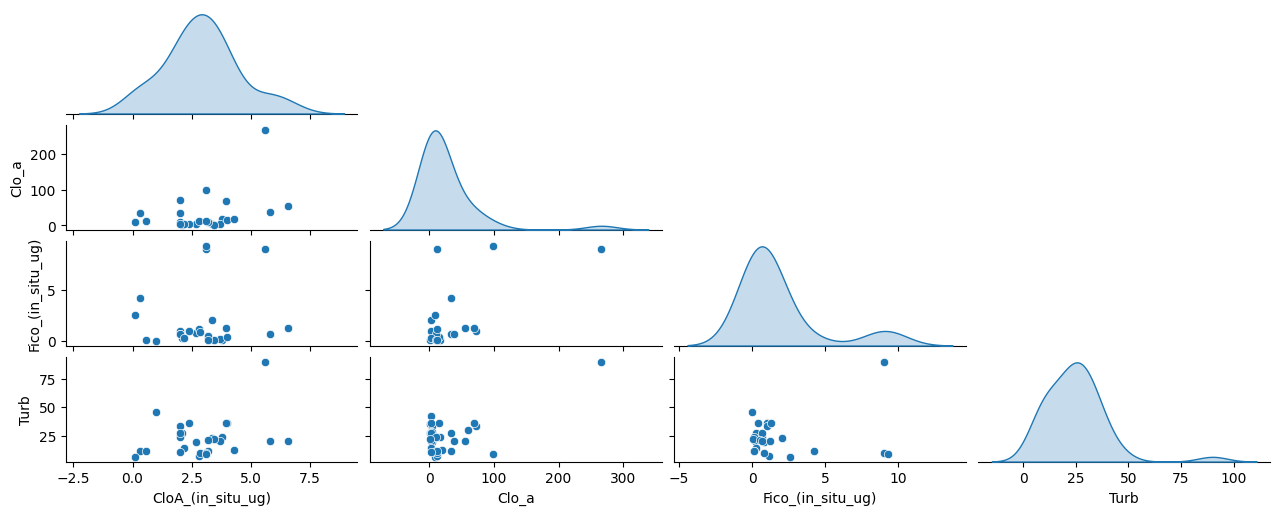

In [58]:
# Filtrar só os parâmetros de interesse
df_filt = monintoreo_bonete[monintoreo_bonete['param'].isin(unique_params2)]

# Colocar no formato wide: cada param em uma coluna
df_wide = df_filt.pivot(index='fecha_muestra', columns='param', values='valor_original')

# Criar scatter plot matrix
sns.pairplot(df_wide[unique_params2], diag_kind='kde', height=1.3, aspect=2.5, corner=True)


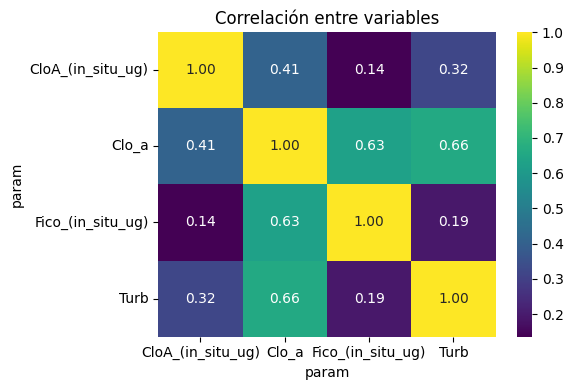

In [59]:
plt.figure(figsize=(6, 4))  # largura=12, altura=6 polegadas
sns.heatmap(df_wide.corr(), cmap="viridis", annot=True, fmt=".2f")
plt.title("Correlación entre variables")
plt.tight_layout()
plt.show()

In [61]:
monintoreo_bonete[monintoreo_bonete["param"] == 'Clo_a'].nlargest(
    5, 'valor_original')[['fecha_muestra', 'valor_original']]#.columns

,fecha_muestra,valor_original
323613,2022-03-15,266.4
434610,2025-02-06,99.2
239470,2023-01-03,71.7
345004,2023-03-02,69.1
266886,2020-12-09,59.2


In [60]:
monintoreo_bonete[monintoreo_bonete["param"] == 'Fico_(in_situ_ug)'].nlargest(
    5, 'valor_original')[['fecha_muestra', 'valor_original']]#.columns

,fecha_muestra,valor_original
434628,2025-02-06,9.30
323631,2022-03-15,9.00
431479,2025-01-14,9.00
385260,2024-01-08,4.21
392905,2024-03-06,2.58
